# Maken generieren

## Brain mask

In [11]:
import numpy as np
import matplotlib.pyplot as plt

data_for_mask = np.load('MetabMaps/Lesion_Double_GT/water_amp_Lesion_Double_GT_Orig.npy')[...,-1]

mx = np.nanmax(data_for_mask)              # ignoriert NaNs
threshold = 0.01 * mx
brain_mask = (data_for_mask > threshold).astype(np.uint8)

# optional: NaNs explizit auf 0 setzen
brain_mask[np.isnan(data_for_mask)] = 0

# Lesion mask (big)

In [12]:
import nibabel as nib
import numpy as np

# NIfTI laden
nii = nib.load("Lesion_Double_lr.nii")

# als NumPy-Array (float64)
Lesion_mask = nii.get_fdata()

Lesion_mask = np.swapaxes(Lesion_mask, -1, 0)

print(Lesion_mask.shape, Lesion_mask.dtype)


(21, 22, 22) float64


# Lac mask

In [13]:
# data_for_Les_mask = np.load('MetabMaps/Lesion_Double_GT/Lac_amp_Lesion_Double_GT_Orig.npy')[...,-1]

# mx = np.nanmax(data_for_Les_mask)              # ignoriert NaNs
# threshold = 0.2 * mx
# Lesion_mask = (data_for_Les_mask > threshold).astype(np.uint8)

# # optional: NaNs explizit auf 0 setzen
# Lesion_mask[np.isnan(data_for_Les_mask)] = 0

# Define helper Function for RMSE over time

In [14]:
import os
import numpy as np

def load_metab_map(root, method, metabolite, suffix="Orig"):
    """
    Loads: {root}/{method}/{metabolite}_amp_{method}_{suffix}.npy
    """
    fname = f"{metabolite}_amp_{method}_{suffix}.npy"
    path = os.path.join(root, method, fname)
    return np.load(path)

def load_multiple_metab_maps(root, methods, metabolite, suffix="Orig"):
    """
    methods: List of methods 

    returns: List of Metab Maps
    """
    return [load_metab_map(root, m, metabolite, suffix) for m in methods]

# def relative_rmse(gt, pred, mask, eps=1e-12):
#     """
#     gt, pred: arrays with shape (x,y,z)
#     mask: boolean or {0,1} array broadcastable to gt without time OR with time
#     returns: rRMSE
#     """

#     mask = mask.astype(bool) & np.isfinite(gt) & np.isfinite(pred)
#     rmse = np.sqrt(np.mean((gt[mask] - pred[mask])**2))/(np.max(gt[mask])-(np.min(gt[mask])))

#     return rmse

def relative_rmse(gt, pred, mask, eps=1e-12):
    """
    gt, pred: arrays with shape (x,y,z)
    mask: array in {0,1} OR [0,1] (PV weights), broadcastable to gt
    returns: relative RMSE
    """

    m = np.asarray(mask, dtype=np.float64)
    valid = np.isfinite(gt) & np.isfinite(pred) & np.isfinite(m) & (m > 0)

    if not np.any(valid):
        return np.nan

    diff2 = (gt[valid] - pred[valid])**2
    rmse = np.sqrt(np.sum(m[valid] * diff2) / (np.sum(m[valid]) + eps))

    # same normalization logic as before, but restricted to ROI
    denom = (np.max(gt[valid]) - np.min(gt[valid])) + eps

    return rmse / denom

def relative_rmse_time(gt, pred, mask, eps=1e-12):
    """
    Returns relative RMSE as a function of time (last index)
    """
    T = gt.shape[-1]
    RMSE = []

    for i in range(0,T):
        RMSE.append(relative_rmse(gt[..., i], pred[..., i], mask, eps))

    return RMSE

def relative_rmse_time_stats(gt, preds, mask, eps=1e-12):
    """
    preds: list of predictions with same shape as gt

    returns:
        mean_rmse_time, std_rmse_time
    """
    rmses = np.stack([relative_rmse_time(gt, p, mask, eps) for p in preds], axis=0)
    return rmses.mean(axis=0), rmses.std(axis=0)

# ---------- helper ----------
def compute_mean_std_rrmse_time(root, metab, mask, gt_method, rep_methods, suffix="Orig", eps=1e-12):
    """
    rep_methods: dict label -> list of method-folders (reps)
    returns: dict label -> (mean(T,), std(T,))
    """
    gt = load_metab_map(root, gt_method, metab, suffix)

    out = {}
    for label, reps in rep_methods.items():
        preds = load_multiple_metab_maps(root, reps, metab, suffix)
        mean_t, std_t = relative_rmse_time_stats(gt, preds, mask, eps)
        out[label] = (np.asarray(mean_t), np.asarray(std_t))
    return out




Metabo = "Lac" 
MASK = Lesion_mask # brain_mask

Noisy_Reps = ["Lesion_Double_Noisy", "Lesion_Double_tMPPCA_5D", "Lesion_Double_Noisy"]
Deep_Reps = ["Lesion_Double_deep_tMPPCA_5D", "Lesion_Double_tMPPCA_5D", "Lesion_Double_deep_tMPPCA_5D"]
tMPPCA_Reps = ["Lesion_Double_tMPPCA_5D", "Lesion_Double_Noisy", "Lesion_Double_tMPPCA_5D"]

GT_Lac = load_metab_map("MetabMaps", "Lesion_Double_GT", f"{Metabo}")


# Noisy_Lac = load_metab_map("MetabMaps", "Lesion_Double_Noisy", f"{Metabo}")
# Deep_Lac = load_metab_map("MetabMaps", "Lesion_Double_deep_tMPPCA_5D", f"{Metabo}")
# tMPPCA_Lac = load_metab_map("MetabMaps", "Lesion_Double_tMPPCA_5D", f"{Metabo}")

# Noisy = relative_rmse_time(GT_Lac, Noisy_Lac, MASK)
# Deep = relative_rmse_time(GT_Lac, Deep_Lac, MASK)
# tMPPCA = relative_rmse_time(GT_Lac, tMPPCA_Lac, MASK)


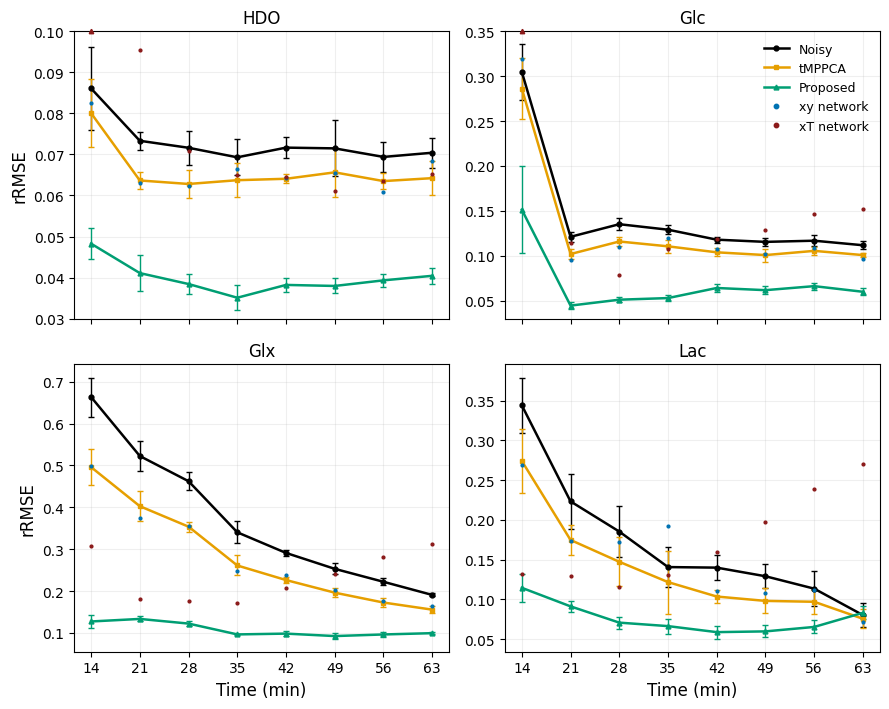

In [32]:
# ---------- USER SETTINGS ----------
root = "MetabMaps"
gt_method = "Lesion_Double_GT"
suffix = "Orig"

Metabo = "Lac"
MASK = Lesion_mask  # oder brain_mask

Noisy_Reps  = [
    "Lesion_double_noisy_1", "Lesion_double_noisy_2", "Lesion_double_noisy_3",
    "Lesion_double_noisy_4", "Lesion_double_noisy_5", "Lesion_double_noisy_6"
]
Deep_Reps   = [
    "Lesion_double_deep_tmppca_1", "Lesion_double_deep_tmppca_2",
    "Lesion_double_deep_tmppca_3", "Lesion_double_deep_tmppca_4",
    "Lesion_double_deep_tmppca_5", "Lesion_double_deep_tmppca_6"
]
tMPPCA_Reps = [
    "Lesion_double_tmppca_1", "Lesion_double_tmppca_2", "Lesion_double_tmppca_3",
    "Lesion_double_tmppca_4", "Lesion_double_tmppca_5", "Lesion_double_tmppca_6"
]

# representative single runs
xy_Network = ["Lesion_double_deep_tmppca_xy_6"]
xT_Network = ["Lesion_double_deep_tmppca_xT_6"]

rep_methods = {
    "Noisy":     Noisy_Reps,
    "tMPPCA":    tMPPCA_Reps,
    "Proposed":  Deep_Reps,
    "xy-only":   xy_Network,
    "xT-only":   xT_Network,
}

metabs = [
    ("water", brain_mask),
    ("Glc",   brain_mask),
    ("Glx",   brain_mask),
    ("Lac",   Lesion_mask),
]

DISPLAY_NAME = {
    "water": "HDO",
    "Glc":   "Glc",
    "Glx":   "Glx",
    "Lac":   "Lac",
}

DISPLAY_METHOD = {
    "Noisy":    "Noisy",
    "tMPPCA":   "tMPPCA",
    "Proposed": "Proposed",
    "xy-only":  "xy network",
    "xT-only":  "xT network",
}

time_axis = np.array([14, 21, 28, 35, 42, 49, 56, 63])


# ===================== PLOTTING =====================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DEFAULT_COLORS = {
    "noisy": "#000000",
    "tMPPCA_5D": "#E69F00",
    "deep_tMPPCA_5D": "#009E73",
    "xy_only": "#0072B2",   # blue
    "xT_only": "#8B1A1A",   # dark red
}

DEFAULT_MARKERS = {
    "noisy": "o",
    "tMPPCA_5D": "s",
    "deep_tMPPCA_5D": "^",
    "xy_only": "o",
    "xT_only": "o",
}

LABEL_TO_SUFFIX = {
    "Noisy": "noisy",
    "tMPPCA": "tMPPCA_5D",
    "Proposed": "deep_tMPPCA_5D",
    "xy-only": "xy_only",
    "xT-only": "xT_only",
}

mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

def plot_fail_with_out_of_range_triangles(ax, x, y, color, ms_dot=1.6, z_dot=5):
    """
    Plot tiny dots for in-range values. For values outside the current y-limits,
    plot a small triangle at the corresponding boundary (journal-safe, no alpha).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    ymin, ymax = ax.get_ylim()

    in_mask = (y >= ymin) & (y <= ymax)
    above = y > ymax
    below = y < ymin

    # in-range: tiny dots (on top)
    if np.any(in_mask):
        ax.plot(
            x[in_mask], y[in_mask],
            linestyle="None",
            marker="o",
            ms=ms_dot,
            color=color,
            zorder=z_dot,
        )

    # out-of-range markers: triangles on the boundary (even if clipped)
    tri_ms = ms_dot + 1.2

    if np.any(above):
        ax.plot(
            x[above], np.full(np.sum(above), ymax),
            linestyle="None",
            marker="^",
            ms=tri_ms,
            color=color,
            zorder=z_dot + 1,
            clip_on=False,
        )

    if np.any(below):
        ax.plot(
            x[below], np.full(np.sum(below), ymin),
            linestyle="None",
            marker="v",
            ms=tri_ms,
            color=color,
            zorder=z_dot + 1,
            clip_on=False,
        )

fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.2), sharex=True)
axes = axes.ravel()

lw_main, ms_main, cap, elw = 1.8, 3.5, 2, 1.0
ms_fail = 2  # extremely small dots for failure cases

legend_labels = list(rep_methods.keys())

# Legend handles: failure cases as marker-only
legend_handles = []
for k in legend_labels:
    suf = LABEL_TO_SUFFIX[k]
    if k in ["xy-only", "xT-only"]:
        legend_handles.append(
            Line2D(
                [0], [0],
                color=DEFAULT_COLORS[suf],
                linestyle="None",
                marker="o",
                ms=ms_fail + 1.2,  # readable in legend
                label=DISPLAY_METHOD[k]
            )
        )
    else:
        legend_handles.append(
            Line2D(
                [0], [0],
                color=DEFAULT_COLORS[suf],
                linestyle="-",
                lw=lw_main,
                marker=DEFAULT_MARKERS[suf],
                ms=ms_main,
                label=DISPLAY_METHOD[k]
            )
        )

for ax, (metab, mask) in zip(axes, metabs):
    curves = compute_mean_std_rrmse_time(
        root, metab, mask,
        gt_method=gt_method,
        rep_methods=rep_methods,
        suffix=suffix
    )

    x = np.asarray(time_axis)

    # --- plot main methods first (so we can then overlay failure markers + triangles) ---
    for lab in legend_labels:
        if lab in ["xy-only", "xT-only"]:
            continue

        mean_t, std_t = curves[lab]
        mean_t = np.asarray(mean_t)
        suf = LABEL_TO_SUFFIX[lab]
        col = DEFAULT_COLORS[suf]
        mk  = DEFAULT_MARKERS[suf]

        ax.errorbar(
            x, mean_t,
            yerr=std_t,
            color=col,
            linestyle="-",
            marker=mk,
            lw=lw_main,
            ms=ms_main,
            capsize=cap,
            elinewidth=elw,
            zorder=3,
        )

    ax.set_title(DISPLAY_NAME.get(metab, metab))
    ax.grid(True, alpha=0.2)
    ax.set_xticks(x)

    # keep readable y-scales (as before)
    if metab == "water":
        ax.set_ylim(0.03, 0.10)
    elif metab == "Glc":
        ax.set_ylim(0.03, 0.35)

    # --- now overlay failure cases with out-of-range triangles ---
    for lab in ["xy-only", "xT-only"]:
        mean_t, _std_dummy = curves[lab]
        mean_t = np.asarray(mean_t)
        suf = LABEL_TO_SUFFIX[lab]
        col = DEFAULT_COLORS[suf]

        plot_fail_with_out_of_range_triangles(
            ax, x, mean_t, col,
            ms_dot=ms_fail,
            z_dot=5
        )

    if ax in (axes[0], axes[2]):
        ax.set_ylabel("rRMSE")
    else:
        ax.set_ylabel("")

axes[2].set_xlabel("Time (min)")
axes[3].set_xlabel("Time (min)")

axes[1].legend(handles=legend_handles, frameon=False, loc="upper right")

fig.tight_layout()
plt.savefig("rrmse_timecourse_2x2.pdf", bbox_inches="tight")
plt.show()
